In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

## Lab 2: Image Stitching with Homographies

In this lab, we will explore image stitching and panorama creation. You will use a homography to register two images together, and implement bilinear interpolation to help accomplish this. As part of the lab, you will also explore image enhancement strategies to improve the quality of image stitching at the seam (the join between two images) relying on your knowledge of image brightness and human perception of this. Collectively, tasks 1-5 will provide a final stitched image. In task 6, you will apply the same code written in tasks 1-5 to create a panorama image using your own photos.

* Task 1: Draw test points on the left image
* Task 2: Use a homography to find the location of these points in the right image
* Task 3: Bilinear interpolation of the right image pixels
* Task 4: Image stitching 
* Task 5: Better blending
* Task 6: Now try your own!

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

# Task 1: Draw test points on the left image

Draw the following points on the left image as red crosses. Display the resulting image.

{446 , 499, 1}, {383, 590, 1}, {296 , 499, 1}, {282, 511, 1}, {401 , 508, 1}

Recall from lectures that these 3-element homogeneous coordinates can be transformed to 2D image pixel coordinates by dividing the first and second elements by the third (needed for later tasks).

In [2]:
# Write your code here

left = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

points_left = np.array([
    [446, 499, 1],
    [383, 590, 1],
    [296, 499, 1],
    [282, 511, 1],
    [401, 508, 1]
], dtype=np.float32)

points_left = points_left[:, :2].astype(np.int32)

left_color = cv2.cvtColor((left * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
for pt in points_left:
    cv2.drawMarker(left_color, tuple(pt), (0, 0, 255), markerType=cv2.MARKER_CROSS, thickness=2)



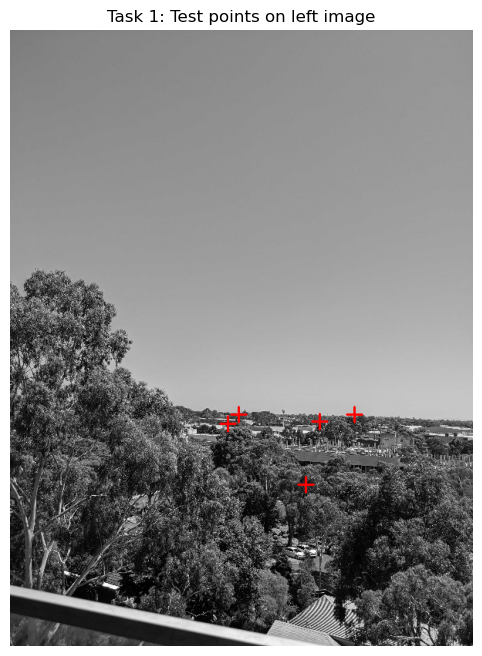

In [3]:
# Show results here
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(left_color, cv2.COLOR_BGR2RGB))
plt.title('Task 1: Test points on left image')
plt.axis('off')
plt.show()


# Task 2: Use Homography to find right image points


The following homography transforms pixel coordinates between the left and right images as
$$ x_R = H x_L $$

\begin{bmatrix}
1.6011 & 0.0277 & -393.5701 \\
0.3242 & 1.5119 & -228.8918 \\
0.0009 & 0.0002 & 1.0000
\end{bmatrix}

Apply the homography to transform the left image points in Task 1 to their corresponding locations in the right image. Draw the transformed points as red crosses on the right image. Check your result before moving on.


Transformed points in right image (x, y):
[[222.72 446.4 ]
 [161.34 538.25]
 [ 68.93 454.92]
 [ 53.17 468.37]
 [179.52 457.54]]


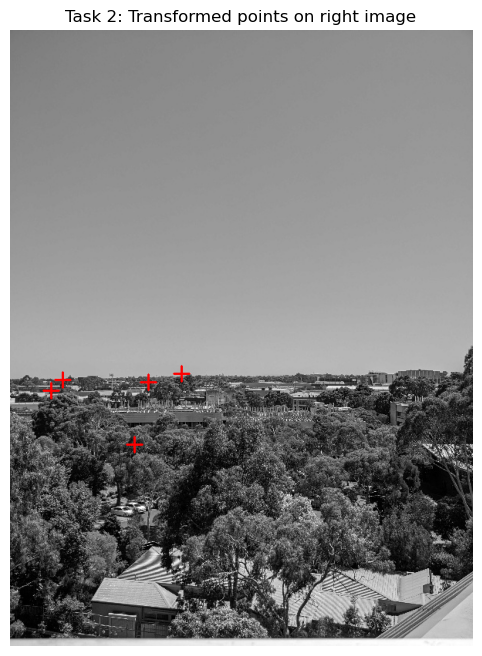

In [4]:
# Write your code here
right = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

H = np.array([
    [1.6011, 0.0277, -393.5701],
    [0.3242, 1.5119, -228.8918],
    [0.0009, 0.0002, 1.0000]
], dtype=np.float32)

points_left_hom = np.hstack((points_left, np.ones((points_left.shape[0], 1), dtype=np.float32)))
points_right_hom = (H @ points_left_hom.T).T
points_right = points_right_hom[:, :2] / points_right_hom[:, 2:3]

print("Transformed points in right image (x, y):")
print(np.round(points_right, 2))

right_color = cv2.cvtColor((right * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
for pt in points_right.astype(np.int32):
    cv2.drawMarker(right_color, tuple(pt), (0, 0, 255), markerType=cv2.MARKER_CROSS, thickness=2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(right_color, cv2.COLOR_BGR2RGB))
plt.title('Task 2: Transformed points on right image')
plt.axis('off')
plt.show()

In [5]:
# Print results here


# Task 3: Bilinear interpolation of the right image

The transformed coordinates can be in between pixel locations. Write a bilinear interpolation function to compute the intensity of the transformed pixel coordinate in right.jpg using intensity values from neighbouring pixel locations. Print the interpolated intensity value for each transformed point in Task 2. The first point should be around 176 whereas the last point should be around 73.

HINT: The bilinear interpolation function should take the transformed pixel coordinate and the intensity values of its four neighbours as input arguments, and should output the interpolated intensity value.

In [2]:
# Write your code here
# Task 3: Bilinear interpolation function
def bilinear_interpolate(img, x, y):
    """Bilinear interpolation for a grayscale image (float32 0-1)."""
    h, w = img.shape
    x0 = int(np.floor(x))
    y0 = int(np.floor(y))
    x1 = x0 + 1
    y1 = y0 + 1

    if x0 < 0 or y0 < 0 or x1 >= w or y1 >= h:
        return 0.0

    Ia = img[y0, x0]
    Ib = img[y0, x1]
    Ic = img[y1, x0]
    Id = img[y1, x1]

    # Fractional parts
    dx = x - x0
    dy = y - y0

    # Bilinear formula
    value = (Ia * (1 - dx) * (1 - dy) +
             Ib * dx * (1 - dy) +
             Ic * (1 - dx) * dy +
             Id * dx * dy)
    return value

print("\nInterpolated intensities for transformed points:")
for i, (x, y) in enumerate(points_right):
    intensity = bilinear_interpolate(right, x, y)
    print(f"Point {i+1}: ({x:.2f}, {y:.2f}) -> intensity ≈ {intensity*255:.1f}")


Interpolated intensities for transformed points:


NameError: name 'points_right' is not defined

In [7]:
# Show results here


# Task 4: Image stitching

Create a 1200x800 (width x height) image and fill the left hand side of this image with the left image. This stitched image will use the left image coordinate system (xl) throughout the stitching process. Next, fill in the remaining pixels on the RHS by transforming their pixel coordinates (left image coordinates) to the right image coordinates via the homography from Task 2 and determining the intensity using your bilinear interpolation implementation. If the right pixel  coordinate is valid, generate the pixel value using bilinear interpolation, but if the right pixel coordinate is invalid, use a pixel value of zero. Display the stitching results. It should look like a wide-angle image with a visible seam where the two images join.

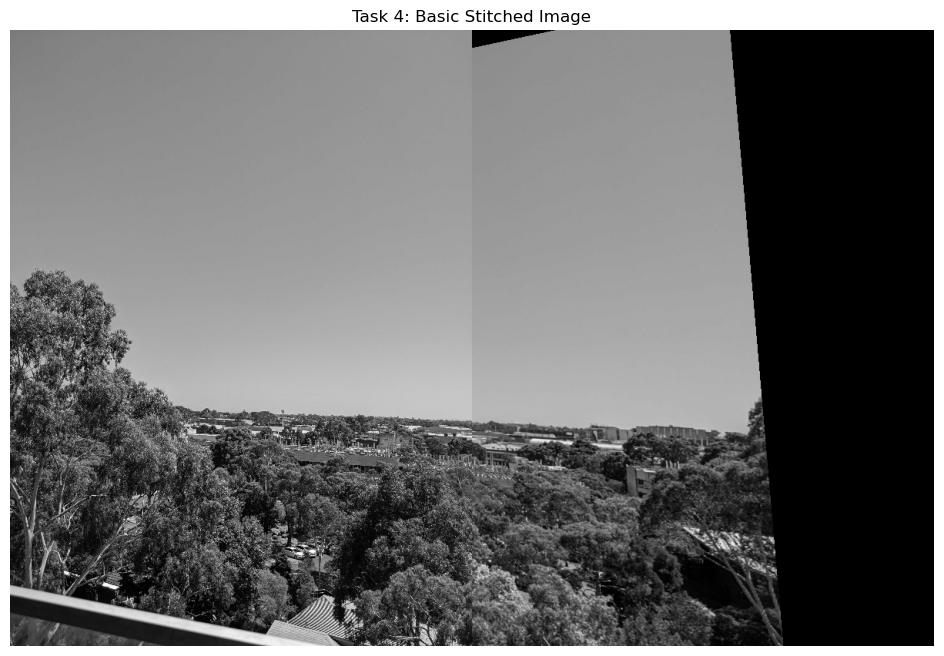

In [8]:
# Write your code here
# Task 4: Basic image stitching (using left image coordinate system)
height, width = left.shape
stitched = np.zeros((800, 1200), dtype=np.float32)   # as specified

# Fill left part with left image
stitched[:height, :width] = left

# Fill right part by inverse warping (transform left coords -> right coords)
for y in range(800):
    for x in range(1200):
        if x < width and y < height:
            continue  # already filled with left
        # Transform (x, y) in stitched (left coord) to right image coord
        p_hom = np.array([x, y, 1], dtype=np.float32)
        p_right_hom = H @ p_hom
        p_right = p_right_hom[:2] / p_right_hom[2]
        
        xr, yr = p_right
        if 0 <= xr < right.shape[1] and 0 <= yr < right.shape[0]:
            stitched[y, x] = bilinear_interpolate(right, xr, yr)
        # else: remains 0 (black)

plt.figure(figsize=(15, 8))
plt.imshow(stitched, cmap='gray')
plt.title('Task 4: Basic Stitched Image')
plt.axis('off')
plt.show()

In [9]:
# Show results here


# Task 5: Better blending

Improve the visual quality of the stitched image by trying the following image processing techniques:

1. Adjust the width of the output image automatically so that fewer black pixels are
visible 
2. Adjust the brightness (by a scaling factor) of each image so that the seam is less
visible
3. Apply a small amount of Gaussian blur or alpha blending near the seam to make
it less visible
4. Adjust the horizontal location of the seam (it can be moved further to the left as
the right image overlaps into the left by quite a few pixels)

Note that you do not have to try all of the above. However, you will only receive a mark here depending on
• the quality of the stitched image
• whether a serious programming attempt is made to improve the visual quality of the stitched image

Output canvas size: 895 x 650


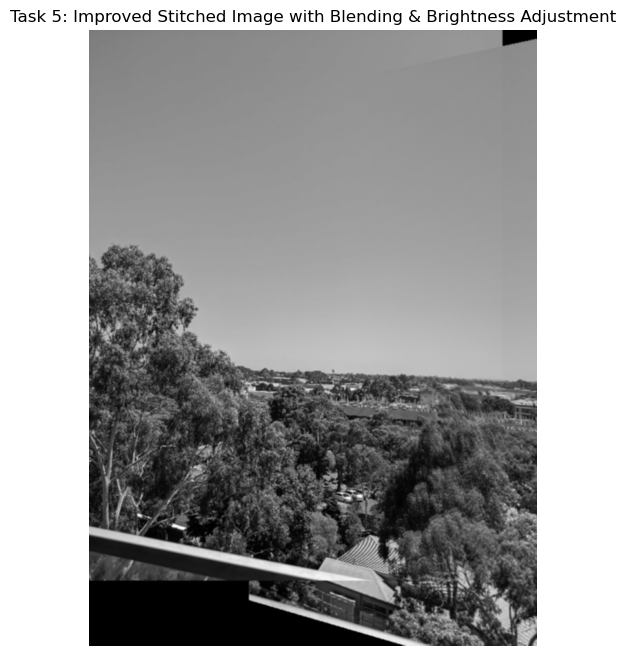

In [9]:
# Write your code here

# Task 5: Better blending

# Assume left, right, and H are already loaded/computed from previous tasks
# left and right should be float32 in [0,1] range

height_l, width_l = left.shape
height_r, width_r = right.shape

# 1. Find better canvas size (reduce black area)
# Find where the four corners of the right image map to in left coordinates
corners_r = np.array([[0, 0, 1],
                      [width_r-1, 0, 1],
                      [width_r-1, height_r-1, 1],
                      [0, height_r-1, 1]], dtype=np.float32).T

corners_left = H @ corners_r
corners_left = corners_left[:2] / corners_left[2]

min_x = int(np.floor(corners_left[0].min()))
max_x = int(np.ceil(corners_left[0].max()))
min_y = int(np.floor(corners_left[1].min()))
max_y = int(np.ceil(corners_left[1].max()))

# Canvas size
out_height = max(height_l, max_y) + 50   # some padding
out_width  = max(width_l, max_x) + 50

print(f"Output canvas size: {out_height} x {out_width}")

# 2. Brightness adjustment (match overlap region)
# Simple global scaling of right image
# You can make this more sophisticated (match histogram in overlap if you want)
right_mean = np.mean(right)
left_mean  = np.mean(left)
scale_factor = left_mean / (right_mean + 1e-8)
right_adj = np.clip(right * scale_factor, 0, 1)

# 3. & 4. Stitching with alpha blending in overlap
stitched = np.zeros((out_height, out_width), dtype=np.float32)

# Fill with left image (on the left side)
stitched[:height_l, :width_l] = left

# Create a weight map for blending (alpha)
# Higher weight for left on the left, gradually transitions to right
seam_x = int(width_l * 0.65)   # Move seam further left (right image overlaps more)

for y in range(out_height):
    for x in range(out_width):
        if x < width_l and y < height_l:
            # Left image region
            alpha = 1.0
            if x > seam_x:                     # in overlap zone
                alpha = (out_width - x) / (out_width - seam_x)   # linear fade
                
            # Get right image coordinate
            p = np.array([x, y, 1.0], dtype=np.float32)
            p_right = H @ p
            xr = p_right[0] / p_right[2]
            yr = p_right[1] / p_right[2]
            
            if 0 <= xr < width_r and 0 <= yr < height_r:
                val_right = bilinear_interpolate(right_adj, xr, yr)
                stitched[y, x] = alpha * left[y, x] + (1 - alpha) * val_right
            else:
                stitched[y, x] = left[y, x] if y < height_l else 0
        else:
            # Only right image
            p = np.array([x, y, 1.0], dtype=np.float32)
            p_right = H @ p
            xr = p_right[0] / p_right[2]
            yr = p_right[1] / p_right[2]
            
            if 0 <= xr < width_r and 0 <= yr < height_r:
                stitched[y, x] = bilinear_interpolate(right_adj, xr, yr)

# Optional: small Gaussian blur on the whole image to reduce any remaining noise
stitched = cv2.GaussianBlur(stitched, (3, 3), 0.8)

# Display
plt.figure(figsize=(15, 8))
plt.imshow(stitched, cmap='gray')
plt.title('Task 5: Improved Stitched Image with Blending & Brightness Adjustment')
plt.axis('off')
plt.show()

In [11]:
# Show results here

# Task 6: Now try your own!

In this final task, you will:
1. Take two images from different perspective of the same scenery and display it
2. Find and match key points across the two images
3. Calculate the homography matrix1 . Print out the homography matrix that you end
up using.
4. Apply image stitching and quality improvement for a final image (from tasks 1 to 5)

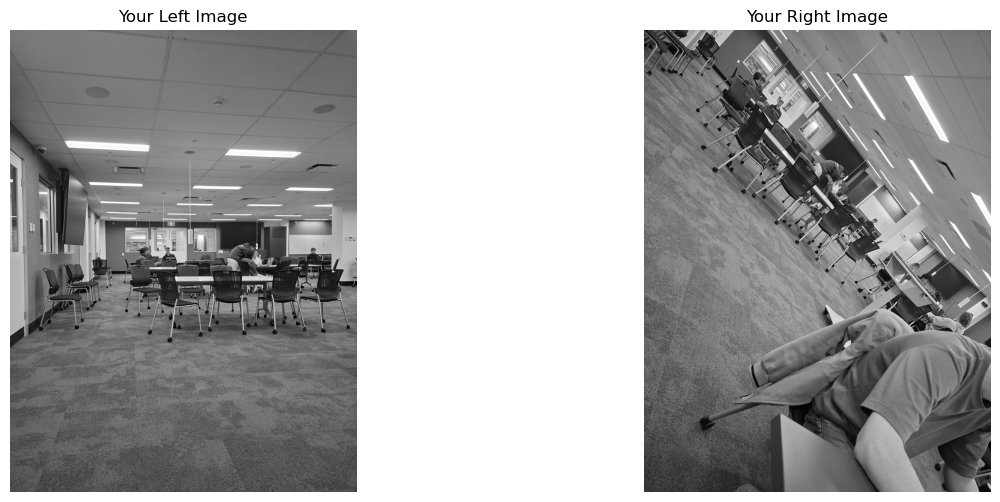

Number of good matches: 8830
Homography matrix computed:
[[ 1.2876000e+00 -9.4810000e-01  1.6766085e+03]
 [ 1.4069000e+00  9.6370000e-01 -2.7627760e+03]
 [ 2.0000000e-04  1.0000000e-04  1.0000000e+00]]


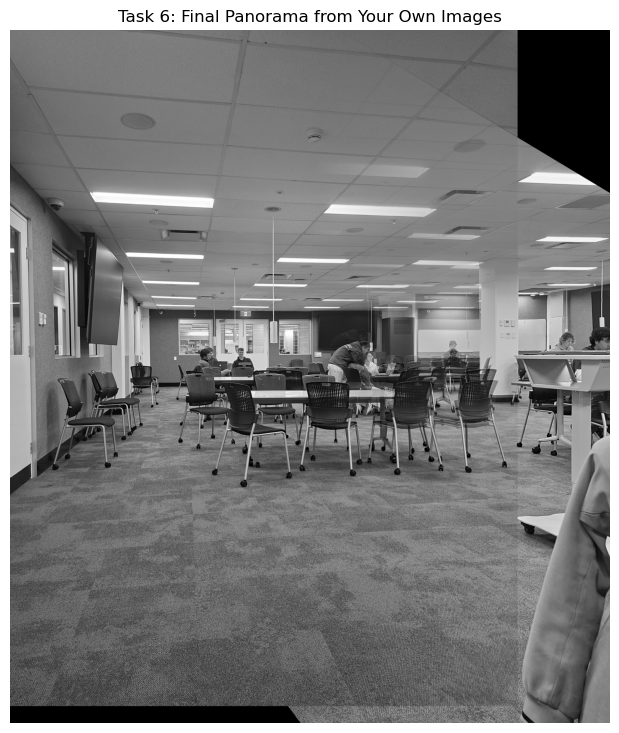

In [3]:
# Write your code here
left_own  = cv2.imread('my_right.jpg',  cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
right_own = cv2.imread('my_left.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

# Display original images
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(left_own, cmap='gray')
plt.title('Your Left Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(right_own, cmap='gray')
plt.title('Your Right Image')
plt.axis('off')
plt.show()

# 2. Find and match keypoints (allowed by the lab)
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute((left_own * 255).astype(np.uint8), None)
kp2, des2 = sift.detectAndCompute((right_own * 255).astype(np.uint8), None)

# Match using BFMatcher + ratio test
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Number of good matches: {len(good_matches)}")

# 3. Compute homography
if len(good_matches) < 8:
    print("Not enough good matches! Try better overlapping photos.")
else:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    H_own, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    print("Homography matrix computed:")
    print(np.round(H_own, 4))

    # 4. Stitch using improved method from Task 5 (with brightness + blending)

    height_l, width_l = left_own.shape
    height_r, width_r = right_own.shape

    # Find bounding box for canvas
    corners_r = np.array([[0, 0, 1],
                          [width_r-1, 0, 1],
                          [width_r-1, height_r-1, 1],
                          [0, height_r-1, 1]], dtype=np.float32).T

    corners_left = H_own @ corners_r
    corners_left = corners_left[:2] / corners_left[2]

    min_x = int(np.floor(corners_left[0].min()))
    max_x = int(np.ceil(corners_left[0].max()))
    min_y = int(np.floor(corners_left[1].min()))
    max_y = int(np.ceil(corners_left[1].max()))

    out_height = max(height_l, max_y) + 100
    out_width  = max(width_l, max_x) + 100

    # Brightness adjustment
    scale_factor = np.mean(left_own) / (np.mean(right_own) + 1e-8)
    right_adj = np.clip(right_own * scale_factor, 0, 1)

    # Create stitched image with alpha blending
    stitched = np.zeros((out_height, out_width), dtype=np.float32)
    stitched[:height_l, :width_l] = left_own

    seam_x = int(width_l * 0.6)   # Move seam left for more overlap

    for y in range(out_height):
        for x in range(out_width):
            p = np.array([x, y, 1.0], dtype=np.float32)
            p_right = H_own @ p
            xr = p_right[0] / p_right[2]
            yr = p_right[1] / p_right[2]

            if 0 <= xr < width_r and 0 <= yr < height_r:
                val_right = bilinear_interpolate(right_adj, xr, yr)

                if x < width_l and y < height_l:
                    # Overlap region - alpha blending
                    alpha = 1.0
                    if x > seam_x:
                        alpha = (out_width - x) / (out_width - seam_x + 1e-6)
                    stitched[y, x] = alpha * left_own[y, x] + (1 - alpha) * val_right
                else:
                    stitched[y, x] = val_right

    # # Light smoothing
    # stitched = cv2.GaussianBlur(stitched, (3, 3), 0.5)

    # Final display
    plt.figure(figsize=(16, 9))
    plt.imshow(stitched, cmap='gray')
    plt.title('Task 6: Final Panorama from Your Own Images')
    plt.axis('off')
    plt.show()

In [13]:
# Show results here

# Discussion:

Write a brief (600 word max) report describing how you solved each task, interpreting the results and pointing to any insights gained along the way. For example, you may wish to explain what a homography is, the conditions under which it can be used. Analyse the stitched images and explain any interesting artifacts you may see and why these occur. You should discuss the reasons for the presence of the image seam, and the strategies you used to improve this, pointing to the theory you have learned in class that guided your solution. Finally, explain any changes you made to the code to apply it to your own images. 

